# 05 - Final Evaluation and Error Analysis

Danh gia model tot nhat tren test set va phan tich loi.

In [3]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
from torch import nn

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.append(str(ROOT / 'src'))

from flowers102.data import build_dataloaders
from flowers102.models import create_model
from flowers102.evaluate import evaluate_model
from flowers102.utils import save_json

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
train_loader, valid_loader, test_loader, train_ds, valid_ds, test_ds = build_dataloaders(
    data_dir="/home/nguyenhuynh/Documents/deep-learning/dataset/flower_data",
    batch_size=32,
    num_workers=0,
    image_size=224,
    use_augmentation=False,
)

num_classes = len(train_ds.classes)
model = create_model('efficientnet_b0', num_classes=num_classes, pretrained=False)
ckpt = torch.load(ROOT / 'checkpoints' / 'baseline_best.pth', map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
criterion = nn.CrossEntropyLoss()

metrics = evaluate_model(model, test_loader, criterion, device=device)
metrics

{'loss': 0.04717990261148911, 'top1': 0.9890109886471022, 'top5': 1.0}

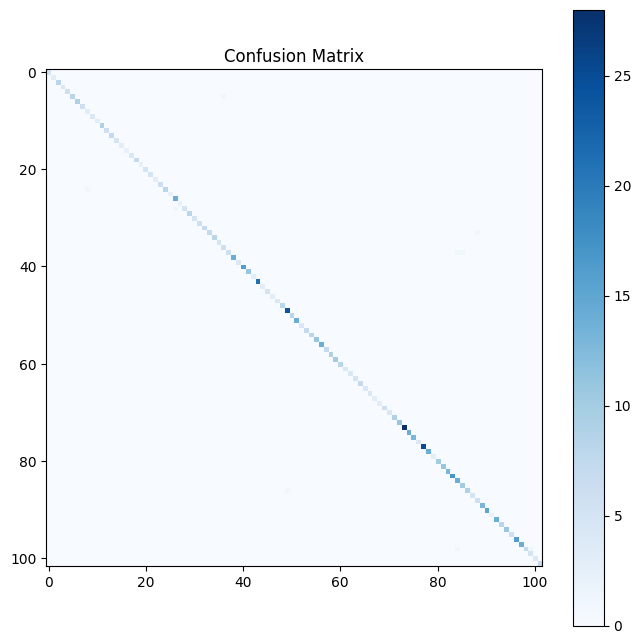

In [5]:
model.eval()
model.to(device)
all_true, all_pred = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(8, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()

In [9]:
class_report = classification_report(all_true, all_pred, output_dict=True, zero_division=0)

with open("/home/nguyenhuynh/Documents/deep-learning/dataset/flower_data/cat_to_name.json", 'r', encoding='utf-8') as f:
    cat_to_name = json.load(f)

payload = {
    'test_metrics': metrics,
    'classification_report': class_report,
    'notes': 'Class index in sklearn report starts from 0 and maps to ImageFolder class order.'
}
save_json(payload, ROOT / 'reports' / 'final_evaluation.json')
print('saved:', (ROOT / 'reports' / 'final_evaluation.json').resolve())

saved: /home/nguyenhuynh/Documents/deep-learning/quangbinh/cv/reports/final_evaluation.json
